# Customer Segmentation with RFM Analysis

Segmenting e-commerce customers based on their purchase behaviour
using Recency, Frequency and Monetary analysis combined with
K-Means clustering.

## 1. Setup & Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel('data/Online Retail.xlsx')
df.head(
)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2.Data cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df = df.dropna(subset=['CustomerID'])
print('Rows after removing missing CustomerIDs:', len(df))

Rows after removing missing CustomerIDs: 406829


In [9]:
print('Negative quantities:', (df['Quantity'] < 0).sum())
print('Negative prices:', (df['UnitPrice'] < 0).sum())

Negative quantities: 8905
Negative prices: 0


In [11]:
df = df[df['Quantity'] > 0]
print('Rows after removing returns:', len(df))

Rows after removing returns: 397924


In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 4. RFM Analysis
### 4.1 Calculating RFM Metrics

In [13]:
reference_date = df['InvoiceDate'].max()
print(reference_date)

2011-12-09 12:50:00


In [14]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      325          1  77183.60
1     12347.0        1          7   4310.00
2     12348.0       74          4   1797.24
3     12349.0       18          1   1757.55
4     12350.0      309          1    334.40


In [15]:
print('Number of customers:', len(rfm))
rfm.describe()

Number of customers: 4339


,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,91.518322,4.271952,2053.793018
std,1721.889758,100.009747,7.705493,8988.248381
min,12346.000000,0.000000,1.000000,0.000000
25%,13812.500000,17.000000,1.000000,307.245000
50%,15299.000000,50.000000,2.000000,674.450000
75%,16778.500000,141.000000,5.000000,1661.640000
max,18287.000000,373.000000,210.000000,280206.020000


In [16]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score
0     12346.0      325          1  77183.60       1       1       4
1     12347.0        1          7   4310.00       4       4       4
2     12348.0       74          4   1797.24       2       3       4
3     12349.0       18          1   1757.55       3       1       4
4     12350.0      309          1    334.40       1       1       2


In [19]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0     12346.0      325          1  77183.60       1       1       4       114   
1     12347.0        1          7   4310.00       4       4       4       444   
2     12348.0       74          4   1797.24       2       3       4       234   
3     12349.0       18          1   1757.55       3       1       4       314   
4     12350.0      309          1    334.40       1       1       2       112   

   RFM_Total  
0          6  
1         12  
2          9  
3          8  
4          4  


### 4.3 Customer Segments

In [20]:
def assign_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(assign_segment)
print(rfm['Segment'].value_counts())

Segment
Champions              1268
At Risk                 988
Potential Loyalists     938
Loyal Customers         843
Lost                    302
Name: count, dtype: int64


### 4.4 Segment Visualisation

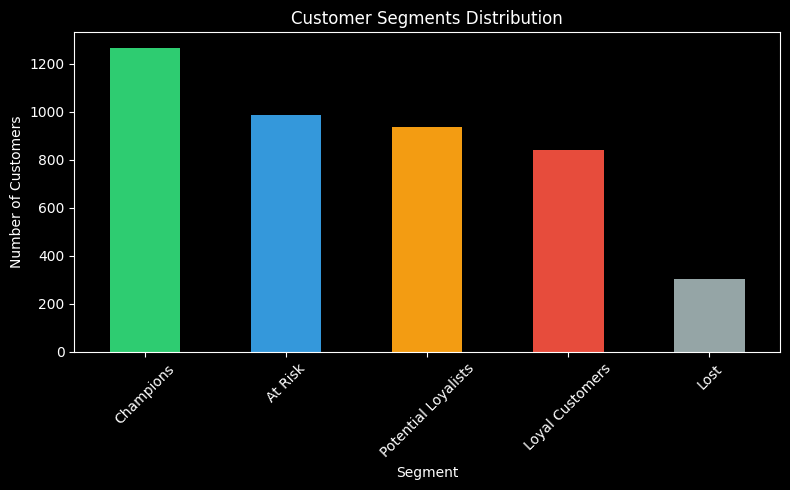

In [21]:
segment_counts = rfm['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
segment_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6'])
ax.set_title('Customer Segments Distribution')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(segment_counts.index, rotation=45)
plt.tight_layout()
plt.show()

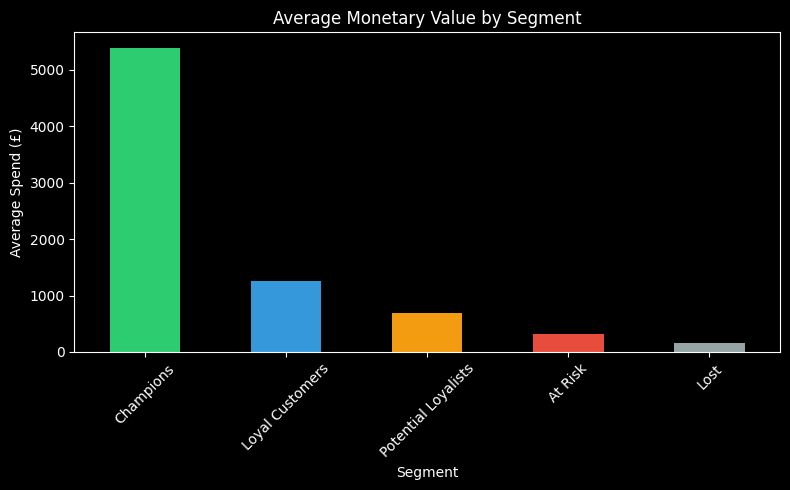

In [22]:
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
segment_monetary.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6'])
ax.set_title('Average Monetary Value by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Average Spend (£)')
ax.set_xticklabels(segment_monetary.index, rotation=45)
plt.tight_layout()
plt.show()

## 5. Insights & Recommendations
### Key Findings
1. Champions (1,268 customers) -the most valuable segment, highest
   average spend and most recent purchases. should: reward and retain.
2. At Risk (988 customers) - second largest segment, these customers
   are showing declining engagement. need to: win-back campaigns with
   targeted discounts.
3. Potential Loyalists (938 customers) - good frequency but not yet
   spending at champion levels. should upsell and cross-sell campaigns.
4. Loyal Customers (843 customers)- consistent buyers but recency
   is dropping. Priority: re-engagement emails and loyalty rewards.

### Business Recommendations
* Focus 60% of marketing budget on Champions and Loyal Customers
* Don't waste budget on Lost customers because the cost of recovery will be high
* Offer Potential Loyalists a loyalty programme to push them to Champion status


